# Attention is all you need!

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

<div align="center">
  <img src="../Medias/Transformer.png" width="300">
</div>

# Encoder block

Given an input of words, like "Your dog is amazing," we start by tokenizing the sentence. In other words, we this string into many smaller pieces call token that our transformer can understand. The token might look like:

<center>
  Your | dog | is | amazing
</center>

Each of these words are assigned a unique ID, called an input ID, which represent their position in our vocabulary list. Each of these ID correspond to a unique embeeding vector (of size 512 in this case). Let $x_i$ represent the embedding vector of our $i$-th word in our input, such that

$$x_i = W_{emb} \cdot x$$

Where $x$ is a one hot vector, such that if the input ID of our word is 4, then the 4th entry of $x$ would be 1, while every other entries is 0. Here, $W_{emb}$ has dimension $( d_{model}, vocab)$.

$$X = [x_1,x_2, ..., x_{seq}]$$
$$X \in \mathbb{R}^{d_{model} \times seq}$$
Here, $d_{model}$ is the size of our embedding vector.

After translating each token into their corresponding embedding matrix, we attempt to encode the positional context of each word. Specifically, we want each token to carry information about its position. We want to treat words that are close to each other physically as being more closely linked, and distant words carrying little relations between each other. We do this via an Positional Embedding Vector given by:

$$PE_{i,j} = \sin \left(\frac{i}{10000^{j/d_{model}}} \right)$$
$$Z = (X + PE)^T$$
$$Z \in \mathbb{R}^{seq \times d_{model}}$$

Where $i$ correlate to $x_i$, $j$ are the elements of the vector, and $d_{model}$ is 512. We choose a trigonometric function to represent the positional encoding vector since if we plot what we did, we get the pattern below. The hope is for the model to recognize the pattern just as we do as humans.

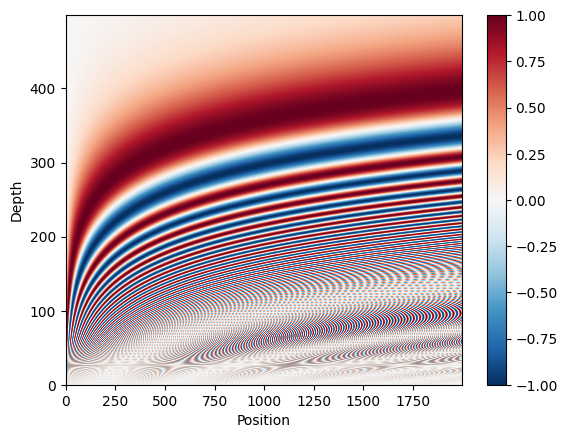

In [9]:
x = np.arange(0,2000)
y = np.arange(0,500)
X, Y = np.meshgrid(x, y)

Z = np.sin(X/(10000**(Y/512)))

im = plt.imshow(Z, aspect='auto', cmap='RdBu_r', origin='lower',
                extent=[x.min(), x.max(), y.min(), y.max()])

plt.colorbar(im) #colorbar
plt.ylabel("Depth")
plt.xlabel("Position")
plt.show()


### Multihead Attention

The next part of the process is multihead attention, which is used to allow the model to relate words to one another. A single head attention is given as such:

$$\text{Attention}(Q,K,V) = \text{Softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$
$$\text{Softmax}(y_i) = \frac{e^{y_i}}{\sum_j e^{y_j}}$$

In this case,  $Q,K,V \in \mathbb{R}^{seq \times d_{model}}$. We apply the softmax function row-wise, such that each row of our new matrix adds up to 1. The process is summarized below, which shows how words relate to each others:

<div align="center">
  <img src="../Medias/Attention.png" width="500">
</div>

Through the matrix multiplication of the softmax function to V, we get back an attention matrix that is exactly our original matrix of size $\mathbb{R}^{seq \times d_k}$. The multihead attention is simply an extention of this, given by the following, where each W matrix is of dimension $(d_{model},d_{model})$:

$$Multihead(Q,K,V) = Concat(head_1, head_2,...,head_h)W^O $$
$$head_i = Attention(QW^Q_i, KW^K_i, VW^V_i)$$

Lets break this down. Each $W_i^Q, W_i^K, W_i^V$ are pieces of their respective $W^Q, W^K, W^V$. Thus, each subpart has dimension ($d_{model}, d_k$) where $d_k = d_{model}/h$ where h is the number of heads. In other words:

$$W = Concat(W_1, W_2, ..., W_h)$$

An equivalent formulation would be to find:

$$Q' = QW^Q$$
$$K' = KW^K$$
$$V' = VW^V$$

And then split each of the $Q',K',V'$ into h equal parts, thus giving us:

$$head_i = Attention(Q'_i,K'_i,V'_i)$$

Each of these Weights matrix are learned during training. In the context of transformer, $Q$ is the query matrix, $K$ is the key matrix, and $V$ is the value matrix. $W^O$ is the output weights that allow each of these indivitual heads to interact and mix useful information.

This multihead approach allow each head to give a different interpretation/information of the sentence. One head might relate a word to another in term of a noun, while another head might relate the same word to a different one in the context of a verb. The following shows this relation.

<div align="center">
  <img src="../Medias/Heads.png" width="550">
</div>

The image shows how 2 different heads give different information on the word "its" as it relates to other aspect of the sentence. We measure this by looking at the matrix of the softmax function, in which the rows are the Query words, while the columns are the Keys. We look at the row associated with "its" and see the value associated with other words.

### Add & Norm

The addition part refers to Residual Addition, in which we add the output of the sublayer with the input itself, given by:

$$X' = X + \text{Sublayer}(X)$$

In the case of our Multihead attention and input of Z, our output is given by:

$$O=Output = Z + \text{Sublayer}(Z)$$

This output is then normalized using a process called layer normalization. For each $o_i$ vector in the output matrix, we find their respective $\mu_i$ and $\sigma_i$. Each element within each vector is given by:

$$o_j = \frac{o_j - \mu_j}{\sqrt{\sigma_j^2 +\epsilon}}\cdot \gamma + \beta$$

Here, $\epsilon$ is a very small constant to prevent division by 0, and $\gamma$ and $\beta$ are learned parameters. In the context of transformer, each vector within $O$ is normalized to have mean of 0 and standard deviation of 1. $\gamma$ and $\beta$ is used to re-scale the data if another distribution is more optimal.

### Encoder Feed Forward

The new matrix is then passed into a fully connect feed-forward neural network. In the original paper, its given 2 layers, so we can easily express it as:

$$FNN(x) = \max{(0, xW_1 + b_1)}W_2 + b_2$$

with $x, W_2$ being a matrix of dim $(seq, d_{model})$, and $W_1$ of dimension ($d_{model}, 4\cdot d_{model}$). Notice how instead of $Wx$, its $xW$. In the context of neural network, we can interpret it as the input layer having $d_{model}$ number of neurons, where each has the value of $x_i \in \mathbb{R}^{seq}$. The middle layer has $4\cdot d_{model}$ number of neurons, and the outer layer returns back to $d_{model}$ number of neurons. The output matrix is thus $(seq, d_{model})$.

Another way to interpret it is that we are passing in each token one at a time into the neural network, and then concatinating all the token afterwards.

## Decoder

The "output" is our target, what we are trying to get the model to learn. So if our input was "Your dog is amazing," our output that we pass in would be "ton chien est incroyable," except we also add an additional \<START\> at the beginner of it. Our tokenized version is thus:

<center>
    <p>&lt;START&gt  | ton | chien | est | incroyable</p>
<center/>


Like with our encoder, we convert each of these tokens into their respective index within our vocabulary, and then translated into an embedding matrix.

### Masked Multi-Head Attention

Our embedding matrix is then passed into a masked multi-head attention layer, which is the same as the our multi-head attention except we do not want our model to see future words and "cheat." We do this through the following transformation:

$$M = \frac{QK^T}{\sqrt{d_v}} + Mask$$
Where $Mask$ is of dimension $(d_{model}, d_{model})$, where every entres above the diagonals are $-\infty$, and every other entres are 0. We then pass this new masked matrix into our softmax function and everything else is kept the same. Even in multihead attention, M is always a square matrix.

### Cross-Attention

Another differences is that of Cross-attention in the second sublayer of the decoder. In this, $K$ and $V$ originates from the encoder, while $Q$ is from the decoder's previous sublayer. This is how the difference in number of tokens between the input and output is resolved.

### Output

Before finishing, we pass it through a linear layer, which converts our matrix back into our vocabulary. It is given by the expression:

$$y = xW_{emb}$$

where $x$ has dimension $(seq, d_{model})$ and $W_{emb}$ has dimension $(d_{model}, vocab)$. Thus our outut has dimension $(seq, vocab)$. Each row still correspond to our original tokens, which gives a prediction of what the next word should be. For example given \<START\>, we expect the next token to be "ton." In our second row, which correspond to "ton," we expect the highest probability to be alloted to "chien." We do this until we reach the last row, where \<END\> should should have the highest probability.

### Training

Like describe above, we choose all of our parameter randomly first, and pass in our inputs text and output in our encoder/decoder. The transformer will then output a string of text, which we then compare to the actual correct text. We then perform a cross-entropy Loss on it, given by:

$$\mathcal{L}_{k} = -\sum_{i,j} y_{i,j} \log(\hat{y}_{i,j})$$

If we wish to compute over a batch, then its simply given by:

$$\mathcal{L}_{total} = \frac{1}{N} \sum_{n=1}^N \mathcal{L}_n$$

We then compute the gradient of this loss function, backpropagate, and refine each parameters to minimize it. Keep in mind that the parameters include:

* $W^Q, W^K, W^V, W^O$, unique for each multihead attention layer.
* $W_1, b_1,W_2, b_2$, unqiue for each FFN layer.
* $\gamma, \beta$, unique for each Add & Norm layer.
* $W_{emb}$


### Inference

Given an input $x$, we can pass in the corresponding output $y$, which starts out as \<START\>. Our transformer will then predict the next word, which is appened to the end of $y$ and is passed in again. This process repeats until our transformer output \<END\>.

Below is an implementation of the original transformer architecture: